In [30]:
library(Seurat)
library(dplyr)
library(ggplot2)

# find candidate genes which may repress tal1 activation in precursor cells

## import scRNAseq result

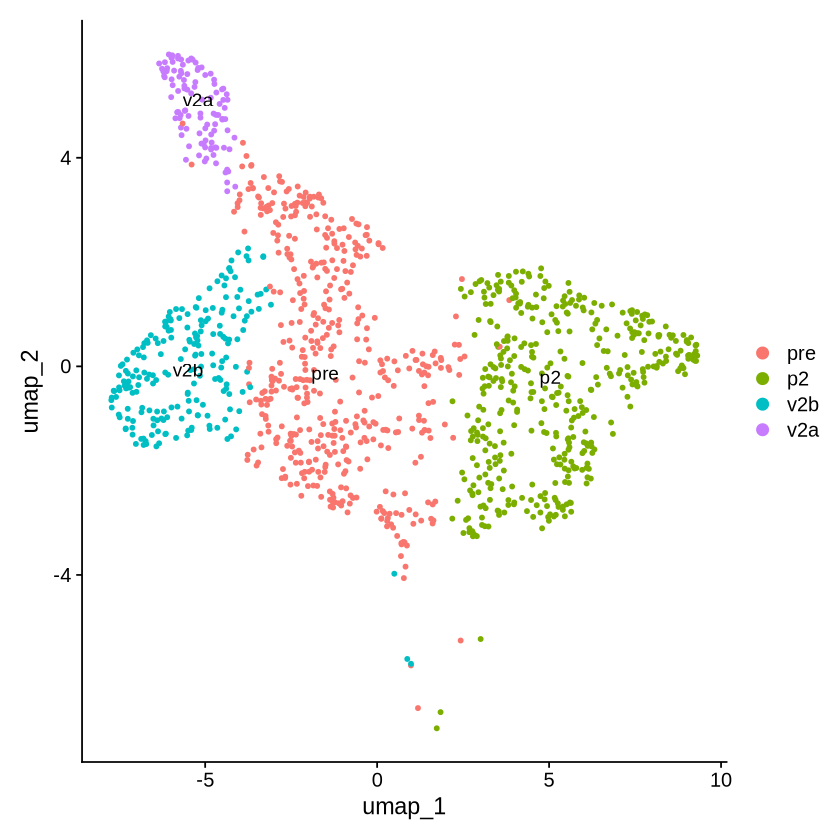

In [3]:
data <- readRDS(file = "/home/wangmei/NGS/scRNA/10x/spinal_vsx1_batch2/v2av2b_rna.rds")
v2av2b_rnaseq <- subset(data, idents = c( "v2a", "v2b", "pre", "p2"))
DimPlot(v2av2b_rnaseq, reduction = "umap", label = TRUE)

## import putative TFs which may bind to tal1 promoter, predicted by animalTFDB4 according to DNA motif analysis

In [4]:
# analyze tal1 upstream repressors
## import candidate genes predicted by animalTFDB4
motifs <- read.csv("TFBSResult_tal1.tsv",sep = "\t", header = T)
motifs <- motifs[motifs$Qvalue < 0.2, ]
dim(motifs)

[1] 5189   10

## match the imported motif name with gene name in scRNAseq result

In [5]:
## match the imported motif name with gene name in scRNAseq result

## extract and unique motif name, change the name to lower case
list.motif <- unique(tolower(motifs$TF))

## rename the motif pattern "nkx6-2" to "nkx6.2"
list.motif.process <- gsub('-', '.', list.motif)

## extract gene name from scRNAseq result
list.rna <- rownames(v2av2b_rnaseq)


## create a function to find fuzzy matches
find_fuzzy_matches <- function(list.rna, list.motif.process) {
  ## change the gene name to lower case
  list.rna.lower <- tolower(list.rna)

  ## store all matched genes
  matched_genes <- c()
  
  ## for each motif gene, perform fuzzy matching
  for (motif_gene in list.motif.process) {
    matches <- grep(paste0("^", motif_gene, "[a-d]?$"), list.rna.lower, value = FALSE)
    if (length(matches) > 0) {
      matched_genes <- c(matched_genes, list.rna[matches])
    }
  }
  
  ## return unique matched genes
  return(unique(matched_genes))
}

## find fuzzy matches using the function
matched_genes <- find_fuzzy_matches(list.rna, list.motif.process)
length(matched_genes)

[1] 501

## find ummatched processed motifs

In [6]:
## find unmatched motifs using the function
find_unmatched_motifs <- function(list.rna, list.motif.process) {
 list.rna.lower <- tolower(list.rna)
  unmatched_motifs <- c()
  
  ## for each motif gene, check if there is a match
  for (motif_gene in list.motif.process) {
    pattern <- paste0("^", tolower(motif_gene), "[a-d]?$")
    matches <- grep(pattern, list.rna.lower)
    
    ## if no match is found, add the gene to the unmatched list
    if (length(matches) == 0) {
      unmatched_motifs <- c(unmatched_motifs, motif_gene)
    }
  }
  
  return(unmatched_motifs)
}

## find unmatched motifs using the function
unmatched_motifs <- find_unmatched_motifs(list.rna, list.motif.process)
length(unmatched_motifs)
sort(unmatched_motifs)

[1] 211

[1] "alx3"    "argfx"   "arntl"   "cdx2"    "creb3"   "creb3l4" "dmrta1" 
  [8] "dmrtc2"  "e2f2"    "e2f6"    "elf5"    "etv3"    "etv6"    "foxc2"  
 [15] "foxr2"   "gm5294"  "hes1"    "hes2"    "hes5"    "hes7"    "hesx1"  
 [22] "hkr1"    "hlx"     "hoxa3"   "hoxd8"   "hsfy1"   "ikzf3"   "isx"    
 [29] "mesp1"   "mzf1"    "nkx2.8"  "pknox1"  "pou3f4"  "pou5f1"  "pou5f1b"
 [36] "prdm6"   "prrx2"   "rarb"    "rbak"    "rhoxf1"  "sox15"   "spib"   
 [43] "sry"     "t"       "tcfl5"   "tead4"   "tgif2"   "tgif2lx" "tgif2ly"
 [50] "ventx"   "yy2"     "zbtb6"   "zfp105"  "zfp14"   "zfp182"  "zfp260" 
 [57] "zfp263"  "zfp28"   "zfp281"  "zfp3"    "zfp30"   "zfp316"  "zfp319" 
 [64] "zfp354b" "zfp37"   "zfp382"  "zfp42"   "zfp422"  "zfp516"  "zfp526" 
 [71] "zfp532"  "zfp574"  "zfp583"  "zfp641"  "zfp654"  "zfp689"  "zfp69"  
 [78] "zfp69b"  "zfp74"   "zfp771"  "zfp775"  "zfp786"  "zfp787"  "zfp800" 
 [85] "zfp82"   "zfp90"   "zik1"    "zkscan1" "zkscan2" "zkscan3" "zkscan5"
 [92] "zkscan7" "znf10"   "znf135"  "znf136"  "znf16"   "znf174"  "znf182" 
 [99] "znf212"  "znf22"   "znf222"  "znf225"  "znf235"  "znf24"   "znf25"  
[106] "znf250"  "znf254"  "znf263"  "znf264"  "znf280a" "znf282"  "znf283" 
[113] "znf287"  "znf3"    "znf300"  "znf304"  "znf311"  "znf317"  "znf324" 
[120] "znf334"  "znf337"  "znf33a"  "znf33b"  "znf34"   "znf343"  "znf35"  
[127] "znf354a" "znf354b" "znf37a"  "znf382"  "znf384"  "znf41"   "znf415" 
[134] "znf416"  "znf418"  "znf419"  "znf429"  "znf431"  "znf432"  "znf436" 
[141] "znf442"  "znf444"  "znf445"  "znf449"  "znf454"  "znf460"  "znf467" 
[148] "znf468"  "znf484"  "znf487"  "znf501"  "znf502"  "znf506"  "znf530" 
[155] "znf534"  "znf543"  "znf547"  "znf548"  "znf549"  "znf554"  "znf555" 
[162] "znf563"  "znf565"  "znf567"  "znf570"  "znf573"  "znf585a" "znf594" 
[169] "znf597"  "znf613"  "znf614"  "znf619"  "znf662"  "znf681"  "znf682" 
[176] "znf695"  "znf701"  "znf707"  "znf708"  "znf71"   "znf713"  "znf716" 
[183] "znf75a"  "znf75d"  "znf764"  "znf77"   "znf774"  "znf776"  "znf778" 
[190] "znf782"  "znf785"  "znf789"  "znf79"   "znf799"  "znf805"  "znf81"  
[197] "znf879"  "znf880"  "znf891"  "znf93"   "znf98"   "zscan1"  "zscan10"
[204] "zscan16" "zscan2"  "zscan22" "zscan23" "zscan31" "zscan4"  "zscan4c"
[211] "zscan5"

## mannually add genes to macthed gene list if needed

In [7]:
## manually add genes if to matched gene list if needed
suppli.genes <- c("her2", "her1",  "her4.1", "hes2.1", "hes2.2", "her4.2", "her12", "her15.1", "her9", "her6" )
matched_genes <- unique(c(matched_genes, suppli.genes))
length(matched_genes)

[1] 511

## calculate average expression of matched genes in each cell type

In [8]:
## calculate average expression of matched genes in each cell type
avg_exp <- AverageExpression(v2av2b_rnaseq, features = matched_genes)$RNA 
avg_exp_df <- as.data.frame(avg_exp)
avg_exp_df$Gene <- rownames(avg_exp_df)
head(avg_exp_df)  

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


,pre,p2,v2b,v2a,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
e2f7,0.059906187,0.362086896,0.02823589,0.000000000,e2f7
pou3f2a,0.046614859,0.080318575,0.03531259,0.058862362,pou3f2a
foxm1,0.020936260,0.452547019,0.00000000,0.017693138,foxm1
foxp2,0.680576918,0.376826384,0.71915126,0.519678156,foxp2
irf5,0.005501642,0.003809551,0.00000000,0.006650391,irf5
prdm4,0.023098796,0.019806341,0.02492709,0.013380048,prdm4


# select genes which positively express in pre

In [9]:
## select genes which positively express in pre
pre.positive <- avg_exp_df[avg_exp_df$pre > 0.15, ]
dim(pre.positive)
head(pre.positive)

[1] 128   5

,pre,p2,v2b,v2a,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
foxp2,0.6805769,0.3768264,0.7191513,0.51967816,foxp2
nrf1,0.5337509,0.4917505,0.4044177,0.30022477,nrf1
gata3,0.9246195,0.1465764,8.1781805,0.04743105,gata3
nr2c1,0.3988785,0.2978335,0.3851893,0.35374993,nr2c1
arnt2,1.3687060,1.2897490,1.3792969,1.29758275,arnt2
homezb,0.3073386,0.3752048,0.3270237,0.23854207,homezb


# find out genes which express significantly higher in v2a than in v2b

In [10]:
## find genes which express higher in v2a than in v2b
gene.pre <- pre.positive$Gene
gene.pre <- as.character(gene.pre)
v2a.markers <- FindMarkers(v2av2b_rnaseq, ident.1 = "v2a", ident.2 = "v2b", features = gene.pre, only.pos = TRUE)


For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session



In [11]:
## select the significant genes, p_val < 0.05, avg_log2FC > 1
v2a.markers <- v2a.markers[v2a.markers$p_val < 0.05, ]
v2a.markers.sig <- v2a.markers[v2a.markers$avg_log2FC > 1, ]
dim(v2a.markers.sig)

[1] 9 5

In [12]:
v2a.markers.sig

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
vsx2,7.098445e-64,8.608281,0.972,0.009,1.958958e-59
lhx4,6.343786e-44,5.110948,0.794,0.043,1.750695e-39
vsx1,1.636475e-41,2.810030,1.000,0.517,4.516181e-37
nkx6.1,2.034864e-30,4.214819,0.645,0.057,5.615614e-26
LHX3,2.171721e-21,4.090651,0.411,0.009,5.993299e-17
zeb1b,1.319158e-12,1.496323,0.757,0.408,3.640480e-08
insm1b,5.021826e-04,1.443040,0.346,0.175,1.000000e+00
insm1a,1.263028e-03,1.019147,0.327,0.156,1.000000e+00
nkx6.2,1.444382e-03,1.825776,0.159,0.052,1.000000e+00


# check average expression of v2a significant TFs in p2

In [32]:
## check average expression of v2a significant TFs in p2
avg_exp_df[rownames(v2a.markers.sig), ]

,pre,p2,v2b,v2a,Gene
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
vsx2,1.2341788,0.02520809,0.005675024,4.0549325,vsx2
lhx4,1.0226829,0.04197694,0.039016208,1.5027582,lhx4
vsx1,8.5695863,11.20851128,1.187059537,8.3487308,vsx1
nkx6.1,0.6970386,0.43032452,0.061267526,1.2163309,nkx6.1
LHX3,0.1686863,0.15183081,0.021009491,0.4293526,LHX3
zeb1b,1.0140896,0.63989241,0.524546970,1.4838917,zeb1b
insm1b,0.5982837,0.55393748,0.154894344,0.4246874,insm1b
insm1a,0.8745068,8.04666153,0.165211249,0.3350966,insm1a
nkx6.2,0.3996335,0.33114142,0.039211740,0.1464597,nkx6.2


## draw the heatmap of v2a-specific genes, replication of Figure 2H

Centering and scaling data matrix

Warning message:
"Different features in new layer data than already exists for scale.data"


Warning message in DoHeatmap(v2av2b_rnaseq, features = c(rownames(v2a.markers.sig), :
"The following features were omitted as they were not found in the scale.data slot for the RNA assay: 5"


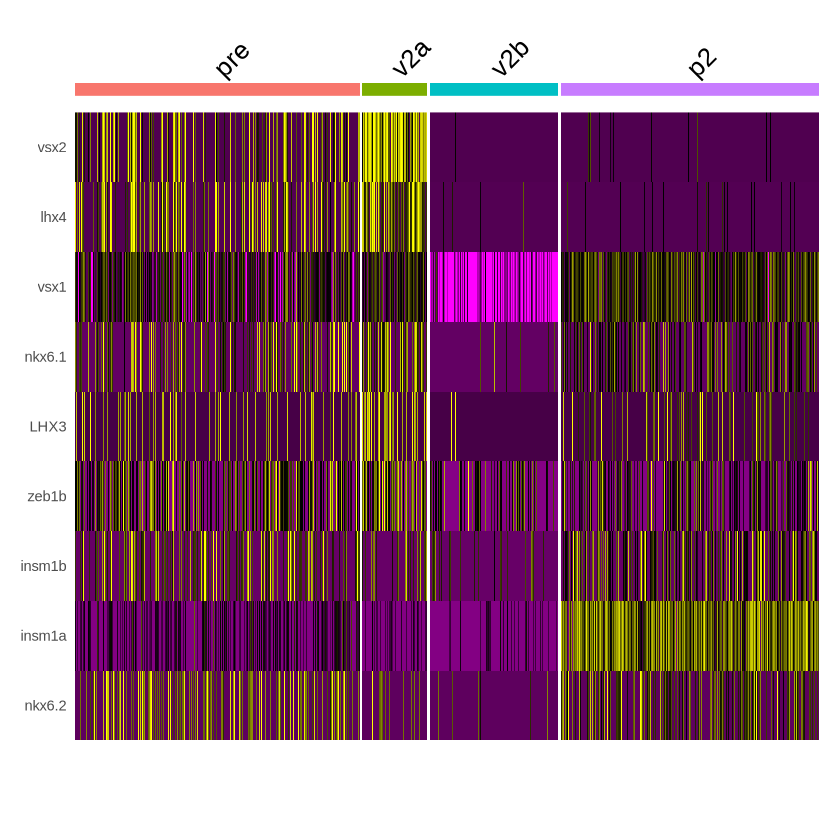

In [13]:
## draw the heatmap of v2a-specific genes, replication of Figure 2H
v2av2b_rnaseq <- ScaleData(v2av2b_rnaseq, features = gene.pre)
v2av2b_rnaseq@active.ident <- factor(
  v2av2b_rnaseq@active.ident,
  levels = c("pre", "v2a", "v2b", "p2")  # set the representation order 
)

DoHeatmap(v2av2b_rnaseq, features = c(rownames(v2a.markers.sig), lines.width = 5)) + NoLegend()

# environment

In [64]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/wangmei/anaconda3/envs/seurat5/lib/libopenblasp-r0.3.27.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] hdf5r_1.3.11            AnnotationHub_3.10.0    BiocFileCache_2.10.1   
 [4] dbplyr_2.5.0            ensembldb_2.26.0        AnnotationFilter_1.26.0
 [7] GenomicFeatures_1.54.1  AnnotationDbi_1.64.1   

In [65]:
sessioninfo::session_info(to_file = "env_v2av2b_multiomic_tal1repressor.md")